# Analise comparação de metaheuristicas para o rTSP

Esse notebook faz diversas analises visuais, que serão usadas ou não na construção de uma monografia

os dados analisados dizem respeito à evolução da melhor solução de cada método

## Análise — resumo dos dados e do notebook

- Objetivo
  - Comparar visualmente metaheurísticas (ga, pso, aco) e bruteforce no rTSP usando evolução da melhor solução e métricas de execução.

- Estrutura dos dados (src/data)
  - <instância>.points — JSON: lista de coordenadas (uso: plot de mapa/rotas).
  - <instância>.graph — (presente no repositório).
  - results/
    - summary/ — JSON por execução (ex.: 10a__aco__s0__h....json)
      - Campos usados: run_id, method, instance, seed, status, started_at, finished_at, timing_file, evolution_file, params
      - result: best_makespan, best_sequence, evaluations, iterations_completed
    - evolution/ — .jsonl por run; linhas com: run_id, method, iter, eval_count, best_makespan, delta, best_sequence
    - timing/ — JSON com durations_ms (load_instance, optimize, serialize, total)

- Convenções e parsing
  - INSTANCE_RE extrai n e label (ex.: "100a" → n=100, label="a") para ordenar/agrupar.
  - METHOD_ORDER = ["bruteforce", "ga", "pso", "aco"] usado em ordenações e cores.

- DataFrames principais gerados
  - summary_df: uma linha por run (colunas conforme summary).
  - evolution_df: uma linha por ponto de evolução (iter).
  - timing_df: tempos por run.
  - runs_df: summary_df mesclado com timing_df e agregados de evolution (colunas extras: seq_len, load_ms, total_ms, improvement_points, last_improvement_eval, last_eval_ratio).

- Visualizações implementadas
  - Heatmap de cobertura (instância × método).
  - Heatmap de melhor makespan por instância/método + linha média por n.
  - Tempo médio por n (linha, escala log) + boxplot por método.
  - Scatter trade-off qualidade × tempo (facetas por n ou medianas agregadas).
  - Curva de convergência (gap mediano ao final vs fração de avaliações).
  - Gap (%) vs bruteforce (heatmap + boxplot) quando disponível.
  - Resumo estatístico por método (runs, instâncias, médias).

- Mapas/rotas
  - Funções: map_load_points, map_normalize_sequence, map_build_full_route, map_pick_run_per_method, map_plot_route, map_setup_axis.
  - Leitura de pontos em <instance>.points e opções de visualização: rota única, comparação lado a lado, painel por método, overlay.
  - Configurações: MAP_RUN_SELECTION, MAP_TARGET_INSTANCE, MAP_PRIMARY_METHOD, MAP_SHOW_NODE_IDS, MAP_SHOW_VISIT_ORDER.

- Observações
  - Notebook tolera ausência de timing/evolution (preenche NaNs).
  - Nomes de arquivos em summary seguem padrão <instance>__<method>__s...__h....json.
  - Pode transformar este resumo em célula README no topo do notebook.


In [21]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from math import ceil

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

METHOD_ORDER = ["bruteforce", "ga", "pso", "aco"]

In [22]:
def resolve_results_dir() -> Path:
    candidates = [
        Path("src/data/results"),
        Path("../src/data/results"),
        Path("/home/heitor/tcc/src/data/results"),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Nao encontrei src/data/results a partir do diretorio atual.")


INSTANCE_RE = re.compile(r"(?P<n>\d+)(?P<label>[A-Za-z]+)$")

MAP_METHOD_COLORS = {
    "bruteforce": "#111111",
    "ga": "#1b9e77",
    "pso": "#d95f02",
    "aco": "#7570b3",
}

def parse_instance(instance_path: str) -> tuple[str, float]:
    instance = Path(instance_path).stem if instance_path else "unknown"
    match = INSTANCE_RE.match(instance)
    n = float(match.group("n")) if match else np.nan
    return instance, n


def instance_sort_key(instance: str) -> tuple[int, str]:
    match = INSTANCE_RE.match(instance)
    if not match:
        return (10**9, instance)
    return (int(match.group("n")), match.group("label"))


def ordered_methods(values: pd.Series) -> list[str]:
    present = list(values.dropna().unique().tolist())
    preferred = [m for m in METHOD_ORDER if m in present]
    extra = sorted([m for m in present if m not in preferred])
    return preferred + extra


def load_summary_df(summary_dir: Path) -> pd.DataFrame:
    rows = []
    for file in sorted(summary_dir.glob("*.json")):
        with file.open("r", encoding="utf-8") as fh:
            obj = json.load(fh)

        result = obj.get("result", {}) or {}
        instance, n = parse_instance(obj.get("instance", ""))

        row = {
            "run_id": obj.get("run_id"),
            "method": obj.get("method"),
            "instance": instance,
            "n": n,
            "seed": obj.get("seed"),
            "status": obj.get("status"),
            "best_makespan": result.get("best_makespan"),
            "best_sequence": result.get("best_sequence", []),
            "evaluations": result.get("evaluations"),
            "iterations_completed": result.get("iterations_completed"),
            "started_at": obj.get("started_at"),
            "finished_at": obj.get("finished_at"),
            "timing_file": obj.get("timing_file"),
            "evolution_file": obj.get("evolution_file"),
        }

        params = obj.get("params", {}) or {}
        for key, value in params.items():
            row[f"param_{key}"] = value

        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce")
    df["finished_at"] = pd.to_datetime(df["finished_at"], errors="coerce")
    df["seq_len"] = df["best_sequence"].apply(lambda x: len(x) if isinstance(x, list) else np.nan)
    return df


def load_timing_df(timing_dir: Path) -> pd.DataFrame:
    rows = []
    for file in sorted(timing_dir.glob("*.json")):
        with file.open("r", encoding="utf-8") as fh:
            obj = json.load(fh)

        durations = obj.get("durations_ms", {}) or {}
        instance, n = parse_instance(obj.get("instance", ""))

        rows.append(
            {
                "run_id": obj.get("run_id"),
                "method": obj.get("method"),
                "instance": instance,
                "n": n,
                "load_ms": durations.get("load_instance"),
                "optimize_ms": durations.get("optimize"),
                "serialize_ms": durations.get("serialize"),
                "total_ms": durations.get("total"),
            }
        )

    return pd.DataFrame(rows)


def load_evolution_df(evolution_dir: Path) -> pd.DataFrame:
    rows = []
    for file in sorted(evolution_dir.glob("*.jsonl")):
        with file.open("r", encoding="utf-8") as fh:
            for line in fh:
                line = line.strip()
                if not line:
                    continue
                obj = json.loads(line)
                rows.append(
                    {
                        "run_id": obj.get("run_id"),
                        "method": obj.get("method"),
                        "iter": obj.get("iter"),
                        "eval_count": obj.get("eval_count"),
                        "best_makespan": obj.get("best_makespan"),
                        "delta": obj.get("delta"),
                        "best_sequence": obj.get("best_sequence", []),
                    }
                )

    df = pd.DataFrame(rows)
    if not df.empty:
        df["seq_len"] = df["best_sequence"].apply(lambda x: len(x) if isinstance(x, list) else np.nan)
    return df



In [23]:
RESULTS_DIR = resolve_results_dir()
SUMMARY_DIR = RESULTS_DIR / "summary"
TIMING_DIR = RESULTS_DIR / "timing"
EVOLUTION_DIR = RESULTS_DIR / "evolution"

summary_raw_df = load_summary_df(SUMMARY_DIR)
timing_df = load_timing_df(TIMING_DIR)
evolution_raw_df = load_evolution_df(EVOLUTION_DIR)

runs_raw_df = summary_raw_df.copy()
if not timing_df.empty:
    timing_cols = ["run_id", "load_ms", "optimize_ms", "serialize_ms", "total_ms"]
    runs_raw_df = runs_raw_df.merge(timing_df[timing_cols], on="run_id", how="left")

if not evolution_raw_df.empty:
    improvements = (
        evolution_raw_df.groupby("run_id", as_index=False)
        .size()
        .rename(columns={"size": "improvement_points"})
    )
    last_eval = (
        evolution_raw_df.groupby("run_id", as_index=False)["eval_count"]
        .max()
        .rename(columns={"eval_count": "last_improvement_eval"})
    )
    runs_raw_df = runs_raw_df.merge(improvements, on="run_id", how="left")
    runs_raw_df = runs_raw_df.merge(last_eval, on="run_id", how="left")
else:
    runs_raw_df["improvement_points"] = np.nan
    runs_raw_df["last_improvement_eval"] = np.nan

runs_raw_df["improvement_points"] = runs_raw_df["improvement_points"].fillna(0).astype(int)
runs_raw_df["last_eval_ratio"] = (
    runs_raw_df["last_improvement_eval"] / runs_raw_df["evaluations"]
).fillna(0.0)

dedup_keys = ["instance", "method", "seed"]
if runs_raw_df.empty:
    runs_df = runs_raw_df.copy()
else:
    runs_df = (
        runs_raw_df.sort_values(
            ["instance", "method", "seed", "finished_at", "started_at", "run_id"],
            ascending=[True, True, True, True, True, True],
            na_position="first",
        )
        .drop_duplicates(subset=dedup_keys, keep="last")
        .reset_index(drop=True)
    )

selected_run_ids = set(runs_df["run_id"].dropna().tolist())
evolution_df = evolution_raw_df[evolution_raw_df["run_id"].isin(selected_run_ids)].copy()
summary_df = runs_df.copy()

SEED_AGG_OPTIONS = {"median": "median", "mean": "mean", "min": "min", "max": "max"}
SEED_AGG_MAKESPAN = "median"
SEED_AGG_RUNTIME = "median"

runs_seed_agg_df = (
    runs_df.groupby(["instance", "n", "method"], as_index=False)
    .agg(
        seeds=("seed", "nunique"),
        runs=("run_id", "count"),
        best_makespan=("best_makespan", SEED_AGG_OPTIONS[SEED_AGG_MAKESPAN]),
        best_makespan_min=("best_makespan", "min"),
        best_makespan_max=("best_makespan", "max"),
        best_makespan_std=("best_makespan", "std"),
        total_ms=("total_ms", SEED_AGG_OPTIONS[SEED_AGG_RUNTIME]),
        total_ms_min=("total_ms", "min"),
        total_ms_max=("total_ms", "max"),
        evaluations=("evaluations", "median"),
        improvement_points=("improvement_points", "median"),
        last_eval_ratio=("last_eval_ratio", "median"),
    )
)
if not runs_seed_agg_df.empty:
    runs_seed_agg_df["best_makespan_std"] = runs_seed_agg_df["best_makespan_std"].fillna(0.0)
    runs_seed_agg_df["mk_range_pct"] = (
        100
        * (runs_seed_agg_df["best_makespan_max"] - runs_seed_agg_df["best_makespan_min"])
        / runs_seed_agg_df["best_makespan_min"]
    ).replace([np.inf, -np.inf], np.nan)
else:
    runs_seed_agg_df["mk_range_pct"] = np.nan

method_order = ordered_methods(runs_raw_df["method"]) if not runs_raw_df.empty else METHOD_ORDER
instance_order = sorted(runs_raw_df["instance"].dropna().unique().tolist(), key=instance_sort_key)

coverage_runs_table = runs_raw_df.pivot_table(
    index="instance", columns="method", values="run_id", aggfunc="count", fill_value=0
)
coverage_runs_table = coverage_runs_table.reindex(index=instance_order, columns=method_order, fill_value=0)

coverage_seeds_table = runs_df.pivot_table(
    index="instance", columns="method", values="seed", aggfunc="nunique", fill_value=0
)
coverage_seeds_table = coverage_seeds_table.reindex(index=instance_order, columns=method_order, fill_value=0)

print(f"results_dir: {RESULTS_DIR}")
print(
    f"runs(raw): {len(runs_raw_df)} | runs(seed_unique): {len(runs_df)} | "
    f"removed_duplicates: {len(runs_raw_df) - len(runs_df)}"
)
print(
    f"summary: {len(summary_raw_df)} | timing: {len(timing_df)} | "
    f"evolution_rows(raw): {len(evolution_raw_df)} | evolution_rows(seed_unique): {len(evolution_df)}"
)
print(f"seed_agg: makespan={SEED_AGG_MAKESPAN}, runtime={SEED_AGG_RUNTIME}")



results_dir: ../src/data/results
runs(raw): 5016 | runs(seed_unique): 4641 | removed_duplicates: 375
summary: 5016 | timing: 5016 | evolution_rows(raw): 90621 | evolution_rows(seed_unique): 83720
seed_agg: makespan=median, runtime=median


In [24]:
print("\n--- sample (seed unico por instancia/metodo/seed) ---")
print(
    runs_df[
        [
            "run_id",
            "instance",
            "method",
            "seed",
            "best_makespan",
            "total_ms",
            "evaluations",
            "improvement_points",
        ]
    ]
    .sort_values(["instance", "method", "seed"])
    .head(12)
)

print("\n--- cobertura por seeds unicas ---")
print(coverage_seeds_table)

print("\n--- cobertura por arquivos de run (inclui duplicatas) ---")
print(coverage_runs_table)

print("\n--- seq_len por metodo ---")
seq_check = runs_df.groupby("method")["seq_len"].agg(["min", "max", "mean", "count"]).reset_index()
print(seq_check)

print("\n--- seeds unicas por metodo ---")
seed_check = runs_df.groupby("method")["seed"].nunique().reset_index(name="unique_seeds")
print(seed_check.sort_values("method"))

if not seq_check.empty and (seq_check["min"] != seq_check["max"]).any():
    print("Aviso: metodo com tamanhos de sequencia inconsistentes.")




--- sample (seed unico por instancia/metodo/seed) ---
                       run_id instance method  seed  best_makespan  total_ms  \
0    100a__aco__s0__h3198f0e2     100a    aco     0     150.876651      6926   
1    100a__aco__s1__h7ea2a381     100a    aco     1     152.422418      2661   
2    100a__aco__s2__hfda660c3     100a    aco     2     149.604073      2751   
3    100a__aco__s3__hff98f998     100a    aco     3     152.834099      2613   
4    100a__aco__s4__h4202e5fb     100a    aco     4     150.958888      2982   
5    100a__aco__s5__h10f42d32     100a    aco     5     153.063223      3193   
6    100a__aco__s6__h42dcff85     100a    aco     6     153.933126      3047   
7    100a__aco__s7__h5934f49c     100a    aco     7     152.605750      3156   
8    100a__aco__s8__he8a16311     100a    aco     8     153.355114      3268   
9    100a__aco__s9__h9970ac0a     100a    aco     9     153.087026      3270   
10  100a__aco__s10__h92701a9e     100a    aco    10     152.44832

In [25]:
if runs_seed_agg_df.empty:
    print("Sem dados agregados por seed para inspecionar variabilidade.")
else:
    print("\n--- variabilidade de makespan entre seeds (por instancia/metodo) ---")
    variability_summary = (
        runs_seed_agg_df.groupby("method")["mk_range_pct"]
        .agg(["count", "median", "mean", "max"])
        .reset_index()
    )
    print(variability_summary)

    print("\n--- top 12 instancia/metodo com maior variacao entre seeds ---")
    top_var = runs_seed_agg_df.sort_values("mk_range_pct", ascending=False).head(12)
    print(
        top_var[
            [
                "instance",
                "method",
                "seeds",
                "best_makespan_min",
                "best_makespan_max",
                "mk_range_pct",
            ]
        ]
    )




--- variabilidade de makespan entre seeds (por instancia/metodo) ---
       method  count     median       mean        max
0         aco     30  13.256246  13.044989  24.834055
1  bruteforce     15   0.000000   0.000000   0.000000
2          ga     30  10.778762  11.728919  24.506544
3         pso     30  19.146839  18.751148  30.145025

--- top 12 instancia/metodo com maior variacao entre seeds ---
    instance method  seeds  best_makespan_min  best_makespan_max  mk_range_pct
71       15a    pso     51          14.087771          18.334533     30.145025
60       14a    pso     51          13.741509          17.586300     27.979392
28       11b    pso     51          10.739354          13.517455     25.868418
56       13c    pso     51          14.024775          17.646572     25.824275
37       12b    aco     51          12.717965          15.876351     24.834055
100      50b     ga     51          49.184777          61.238266     24.506544
68       14c    pso     51          15.1253

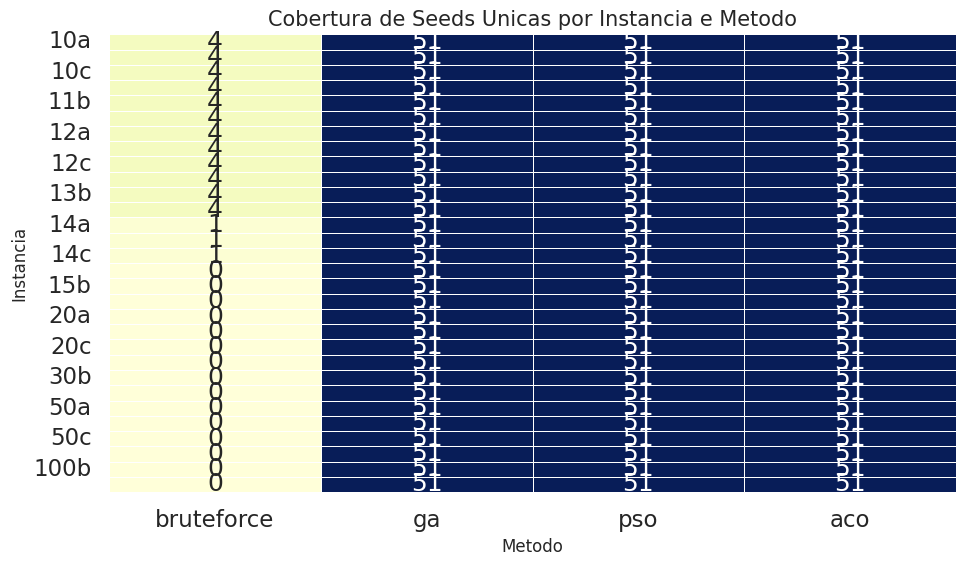

In [26]:
coverage = coverage_seeds_table.copy()

plt.figure(figsize=(10, 6))
sns.heatmap(coverage, annot=True, fmt="d", cmap="YlGnBu", cbar=False, linewidths=0.5)
plt.title("Cobertura de Seeds Unicas por Instancia e Metodo")
plt.xlabel("Metodo")
plt.ylabel("Instancia")
plt.tight_layout()
plt.show()



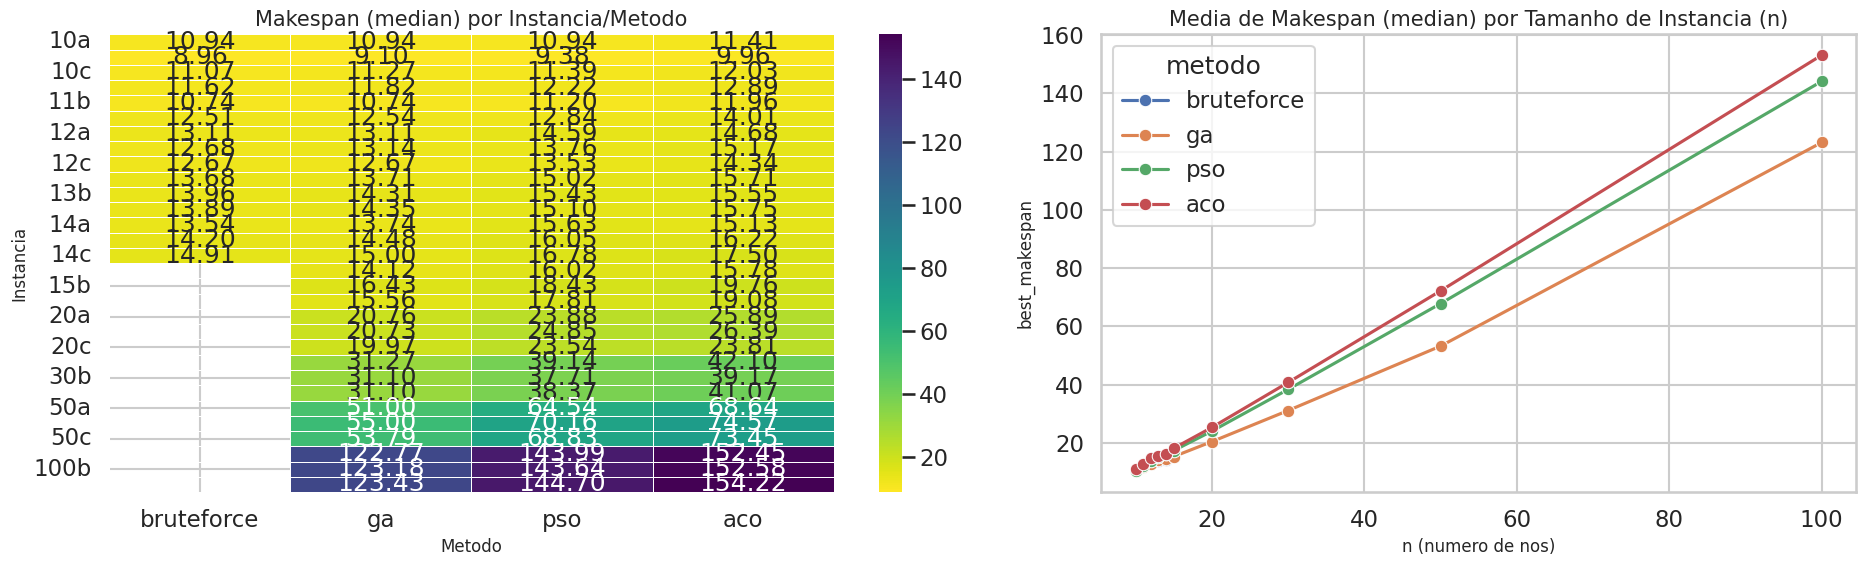

In [27]:
if runs_seed_agg_df.empty:
    print("Sem dados para plotar qualidade agregada por seed.")
else:
    best_matrix = runs_seed_agg_df.pivot_table(
        index="instance",
        columns="method",
        values="best_makespan",
        aggfunc="first",
    )
    best_matrix = best_matrix.reindex(index=instance_order, columns=method_order)

    quality_by_n = (
        runs_seed_agg_df.dropna(subset=["n", "best_makespan"])
        .groupby(["n", "method"], as_index=False)["best_makespan"]
        .mean()
    )

    fig, axes = plt.subplots(1, 2, figsize=(19, 6), gridspec_kw={"width_ratios": [1.2, 1]})
    sns.heatmap(best_matrix, annot=True, fmt=".2f", cmap="viridis_r", linewidths=0.5, ax=axes[0])
    axes[0].set_title(f"Makespan ({SEED_AGG_MAKESPAN}) por Instancia/Metodo")
    axes[0].set_xlabel("Metodo")
    axes[0].set_ylabel("Instancia")

    sns.lineplot(
        data=quality_by_n,
        x="n",
        y="best_makespan",
        hue="method",
        hue_order=method_order,
        marker="o",
        ax=axes[1],
    )
    axes[1].set_title(f"Media de Makespan ({SEED_AGG_MAKESPAN}) por Tamanho de Instancia (n)")
    axes[1].set_xlabel("n (numero de nos)")
    axes[1].set_ylabel("best_makespan")
    axes[1].legend(title="metodo")

    plt.tight_layout()
    plt.show()



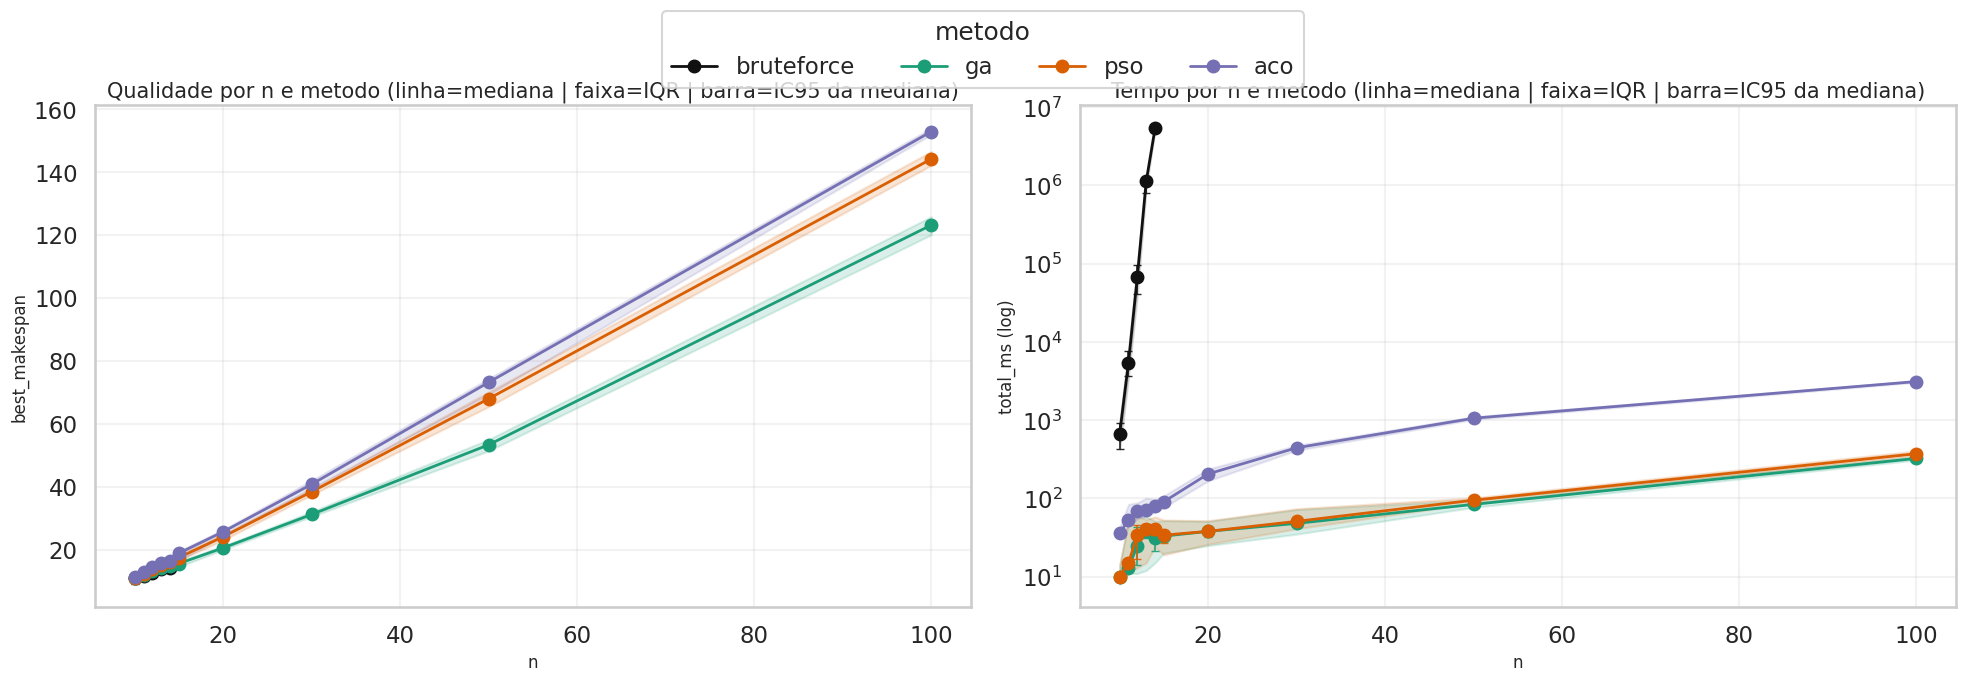

In [28]:
def bootstrap_ci_median(
    values: pd.Series,
    n_boot: int = 1500,
    ci: float = 95.0,
    seed: int = 42,
) -> tuple[float, float]:
    vals = values.dropna().to_numpy(dtype=float)
    if len(vals) == 0:
        return np.nan, np.nan
    if len(vals) == 1 or np.allclose(vals, vals[0]):
        return float(vals[0]), float(vals[0])

    rng = np.random.default_rng(seed)
    samples = rng.choice(vals, size=(n_boot, len(vals)), replace=True)
    medians = np.median(samples, axis=1)
    alpha = (100 - ci) / 2
    return float(np.percentile(medians, alpha)), float(np.percentile(medians, 100 - alpha))


def build_interval_stats(df: pd.DataFrame, value_col: str, seed_offset: int) -> pd.DataFrame:
    rows = []
    grouped = df.dropna(subset=["n", "method", value_col]).groupby(["n", "method"])[value_col]

    for (n, method), series in grouped:
        method_idx = method_order.index(method) if method in method_order else 0
        ci_low, ci_high = bootstrap_ci_median(
            series,
            n_boot=1500,
            ci=95.0,
            seed=seed_offset + int(n) * 31 + method_idx * 101,
        )
        rows.append(
            {
                "n": n,
                "method": method,
                "count": int(series.shape[0]),
                "median": float(series.median()),
                "q1": float(series.quantile(0.25)),
                "q3": float(series.quantile(0.75)),
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )

    return pd.DataFrame(rows)


def plot_interval_band(
    ax: plt.Axes,
    stats_df: pd.DataFrame,
    title: str,
    ylabel: str,
    log_scale: bool = False,
) -> None:
    for method in method_order:
        sub = stats_df[stats_df["method"] == method].sort_values("n")
        if sub.empty:
            continue

        color = MAP_METHOD_COLORS.get(method, None)
        x = sub["n"].to_numpy(dtype=float)
        y = sub["median"].to_numpy(dtype=float)
        q1 = sub["q1"].to_numpy(dtype=float)
        q3 = sub["q3"].to_numpy(dtype=float)
        ci_low = sub["ci_low"].to_numpy(dtype=float)
        ci_high = sub["ci_high"].to_numpy(dtype=float)

        ax.plot(x, y, marker="o", linewidth=2, label=method, color=color)
        ax.fill_between(x, q1, q3, alpha=0.16, color=color)

        yerr = np.vstack([y - ci_low, ci_high - y])
        ax.errorbar(x, y, yerr=yerr, fmt="none", ecolor=color, elinewidth=1.2, capsize=3, alpha=0.9)

    if log_scale:
        ax.set_yscale("log")

    ax.set_title(title)
    ax.set_xlabel("n")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)


if runs_df.empty:
    print("Sem dados para plotar intervalos de qualidade/tempo.")
else:
    quality_stats = build_interval_stats(runs_df, "best_makespan", seed_offset=123)
    runtime_stats = build_interval_stats(runs_df, "total_ms", seed_offset=987)

    if quality_stats.empty or runtime_stats.empty:
        print("Sem dados suficientes para intervalos por n e metodo.")
    else:
        fig, axes = plt.subplots(1, 2, figsize=(20, 7))
        plot_interval_band(
            axes[0],
            quality_stats,
            title="Qualidade por n e metodo (linha=mediana | faixa=IQR | barra=IC95 da mediana)",
            ylabel="best_makespan",
            log_scale=False,
        )
        plot_interval_band(
            axes[1],
            runtime_stats,
            title="Tempo por n e metodo (linha=mediana | faixa=IQR | barra=IC95 da mediana)",
            ylabel="total_ms (log)",
            log_scale=True,
        )

        handles, labels = axes[0].get_legend_handles_labels()
        if labels:
            fig.legend(handles, labels, title="metodo", loc="upper center", ncol=max(1, len(labels)))

        plt.tight_layout(rect=[0, 0, 1, 0.92])
        plt.show()



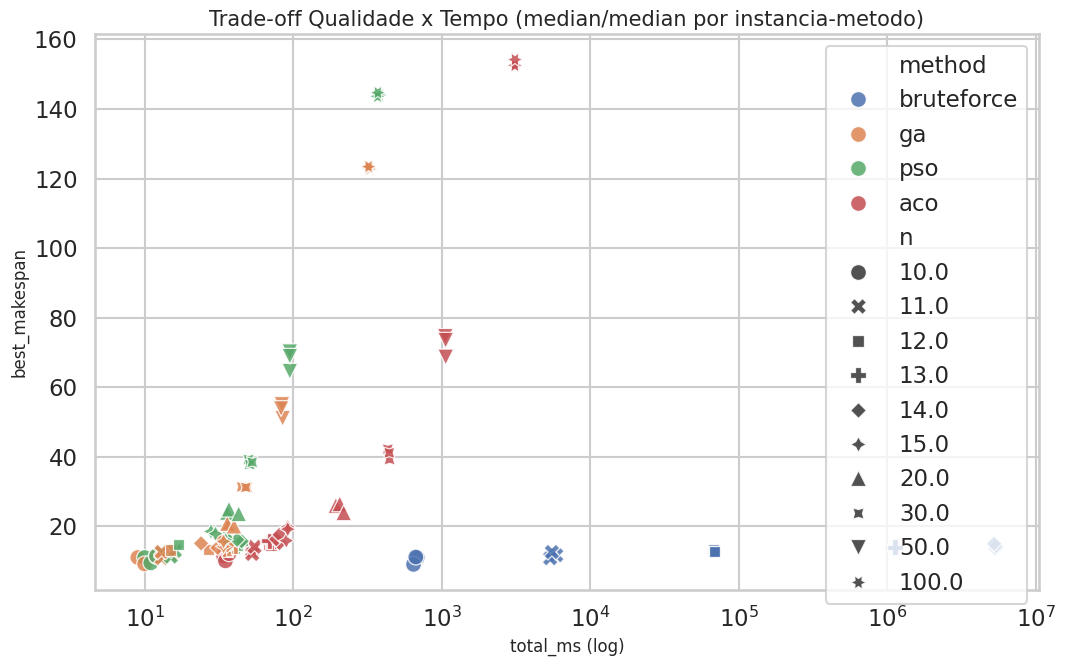

In [29]:
tradeoff = runs_seed_agg_df.dropna(subset=["total_ms", "best_makespan", "n"]).copy()

if tradeoff.empty:
    print("Sem dados suficientes para plotar trade-off agregado.")
else:
    plt.figure(figsize=(11, 7))
    sns.scatterplot(
        data=tradeoff,
        x="total_ms",
        y="best_makespan",
        hue="method",
        hue_order=method_order,
        style="n",
        s=130,
        alpha=0.85,
    )
    plt.xscale("log")
    plt.title(f"Trade-off Qualidade x Tempo ({SEED_AGG_MAKESPAN}/{SEED_AGG_RUNTIME} por instancia-metodo)")
    plt.xlabel("total_ms (log)")
    plt.ylabel("best_makespan")
    plt.tight_layout()
    plt.show()



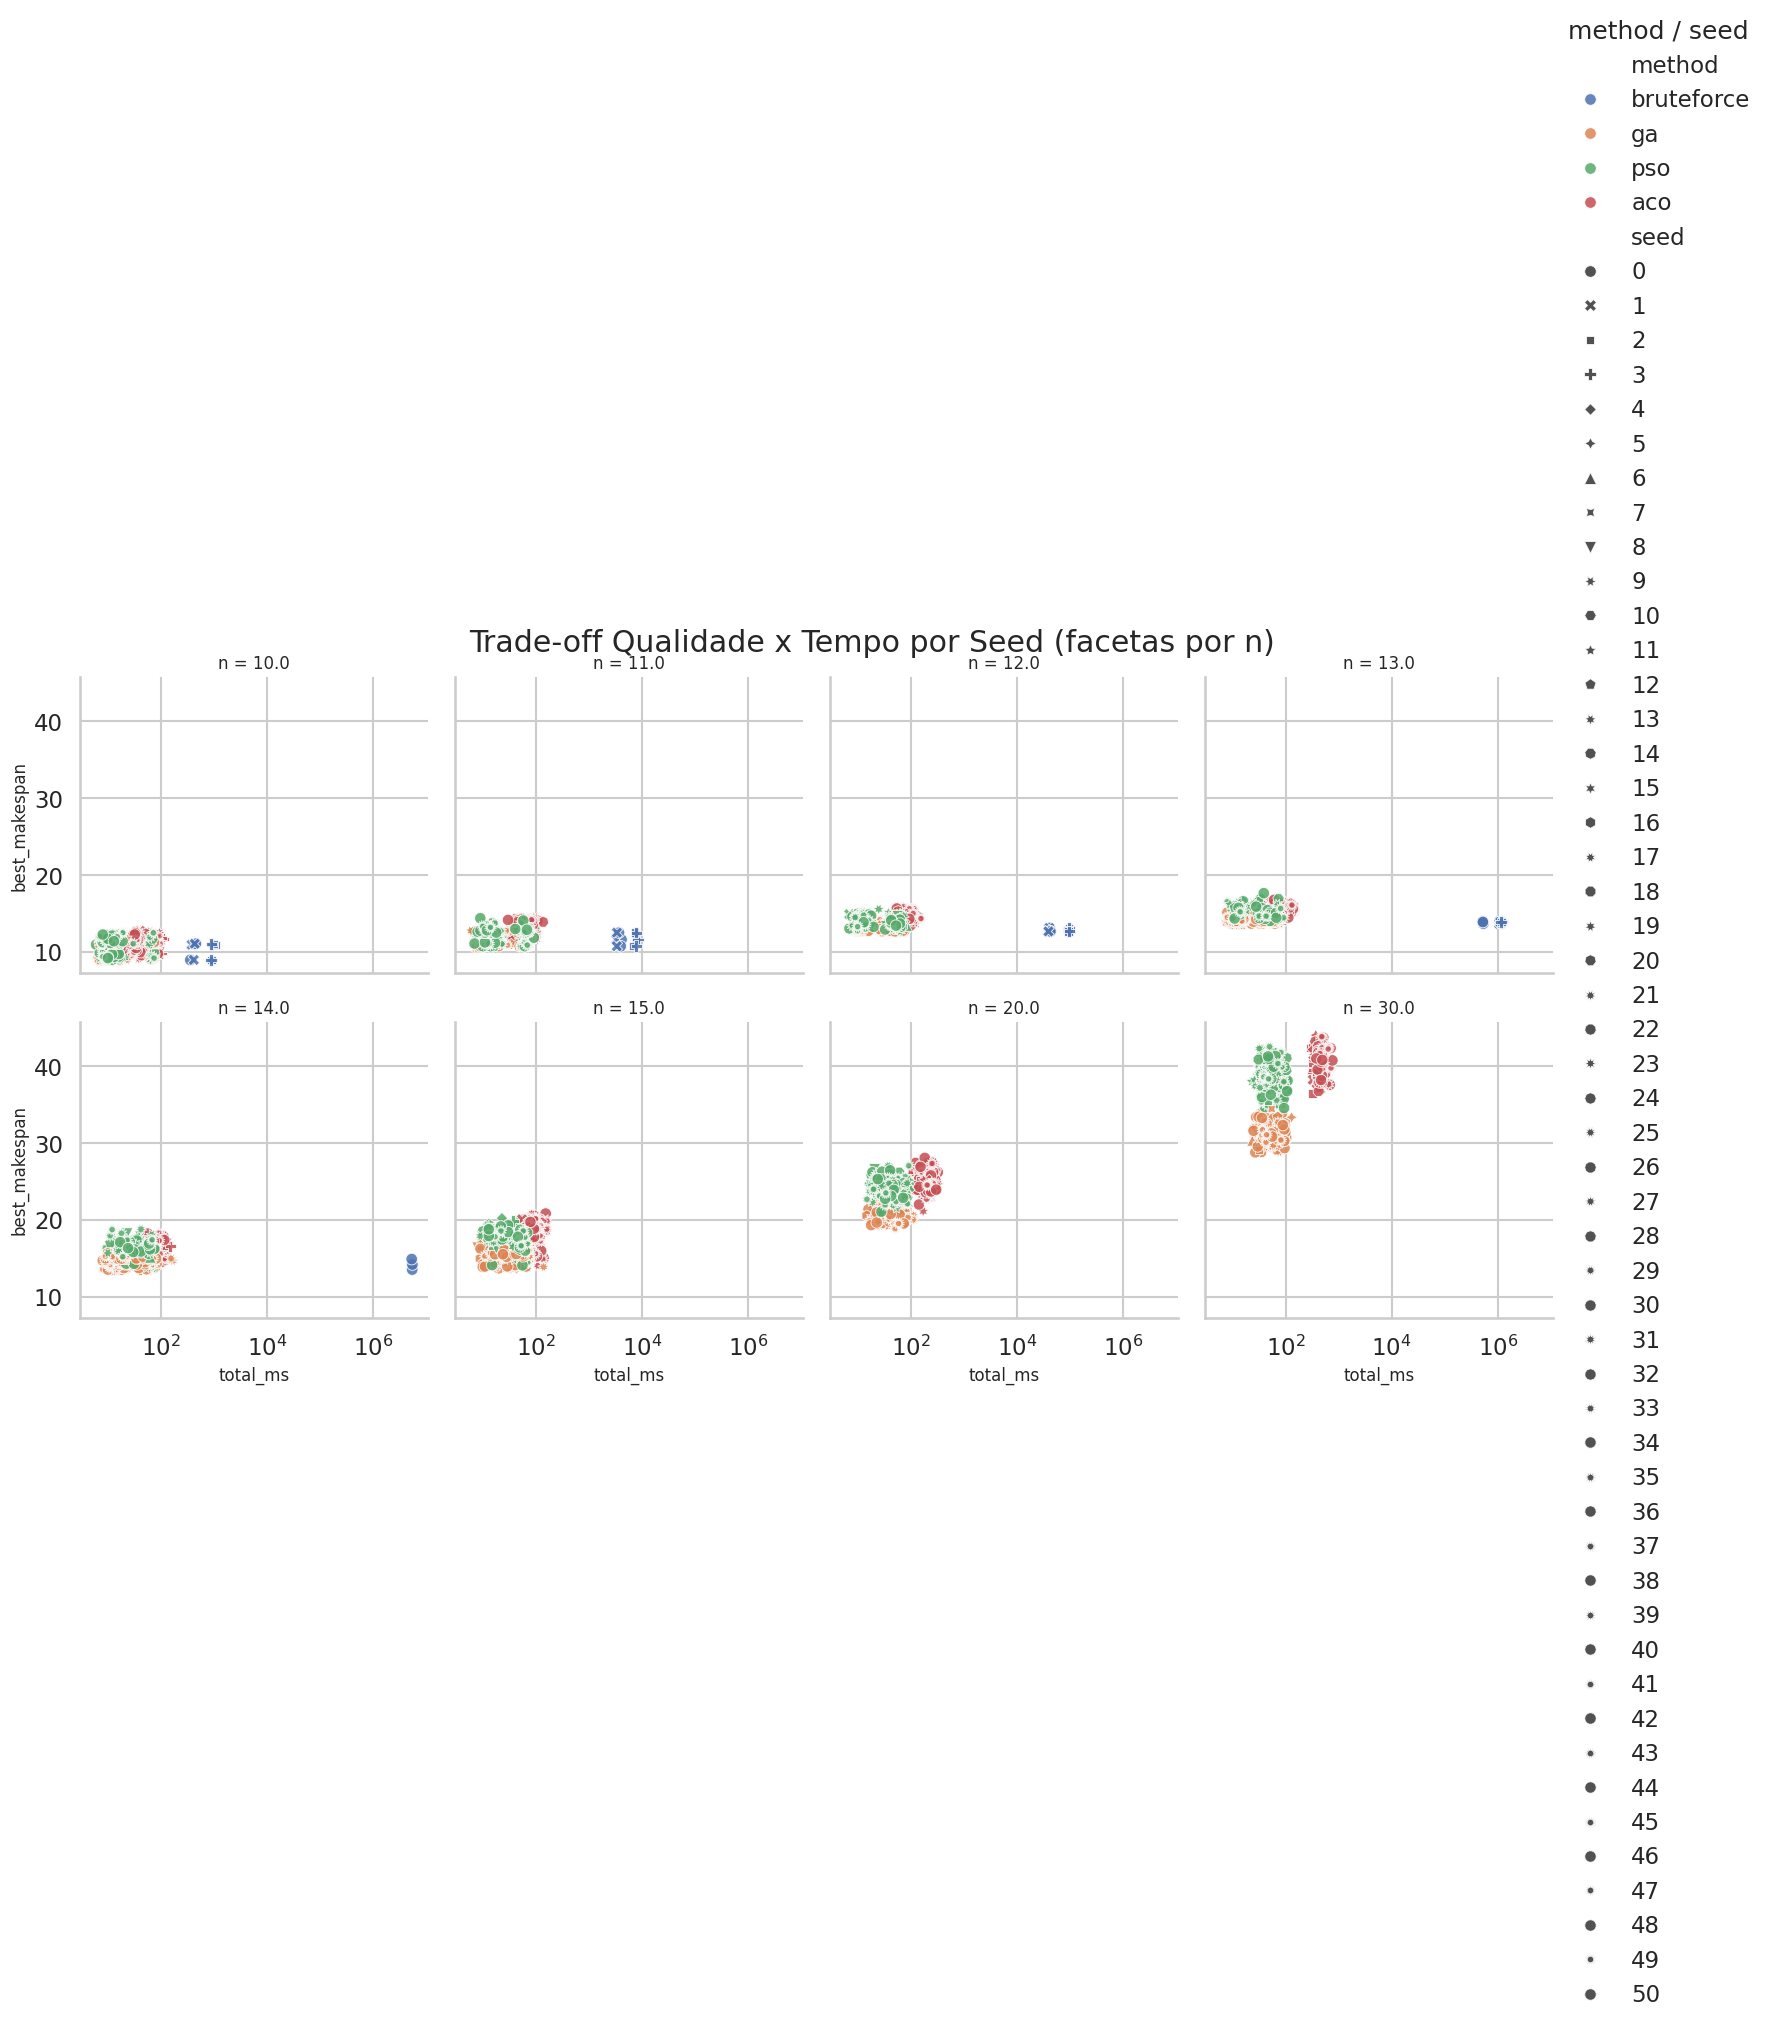

In [30]:
tradeoff_seed = runs_df.dropna(subset=["total_ms", "best_makespan", "n"]).copy()

if tradeoff_seed.empty:
    print("Sem dados suficientes para plotar trade-off por seed.")
else:
    unique_n = sorted(tradeoff_seed["n"].unique())
    selected_n = unique_n if len(unique_n) <= 8 else unique_n[:8]
    trade_sel = tradeoff_seed[tradeoff_seed["n"].isin(selected_n)].copy()

    g = sns.FacetGrid(trade_sel, col="n", col_wrap=4, sharex=True, sharey=True, height=4)
    g.map_dataframe(
        sns.scatterplot,
        x="total_ms",
        y="best_makespan",
        hue="method",
        hue_order=method_order,
        style="seed",
        s=70,
        alpha=0.85,
    )
    for ax in g.axes.flatten():
        ax.set_xscale("log")
    g.add_legend(title="method / seed")
    plt.subplots_adjust(top=0.92)
    g.fig.suptitle("Trade-off Qualidade x Tempo por Seed (facetas por n)")
    plt.show()



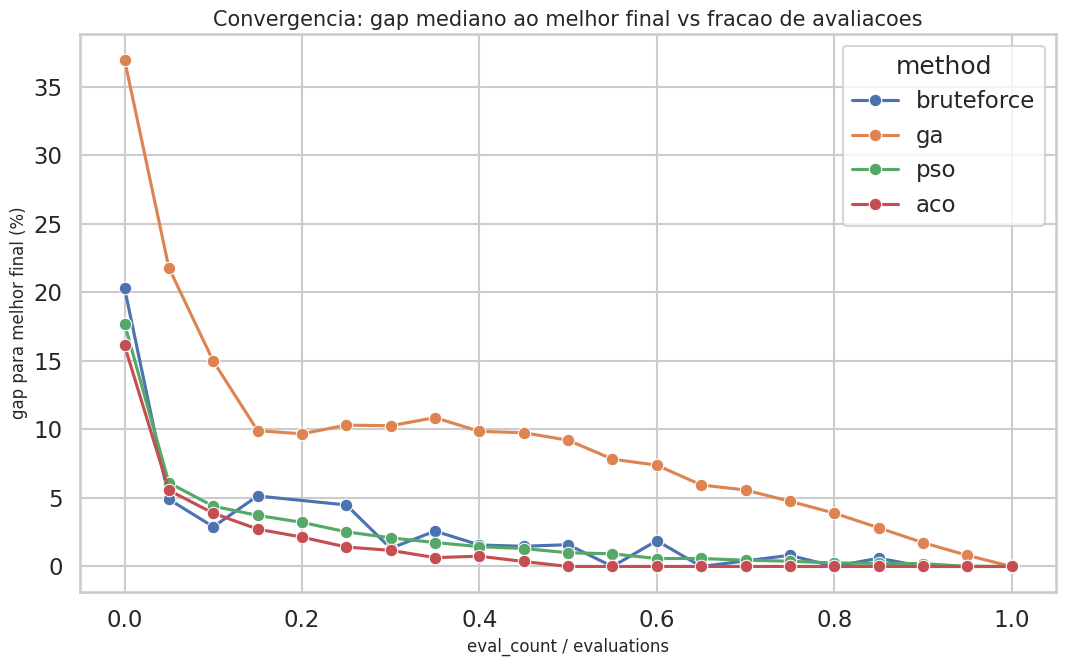

In [31]:
if evolution_df.empty:
    print("Sem dados em evolution para plotar convergencia.")
else:
    evo = evolution_df.merge(
        runs_df[["run_id", "method", "best_makespan", "evaluations"]],
        on=["run_id", "method"],
        how="left",
        suffixes=("", "_final"),
    )
    evo = evo.dropna(subset=["best_makespan_final", "evaluations"]).copy()
    evo = evo[evo["best_makespan_final"] > 0].copy()

    evo["eval_ratio"] = (evo["eval_count"] / evo["evaluations"]).clip(0, 1)
    evo["gap_to_final_pct"] = (
        100 * (evo["best_makespan"] - evo["best_makespan_final"]) / evo["best_makespan_final"]
    )

    final_points = runs_df[["run_id", "method"]].copy()
    final_points["eval_ratio"] = 1.0
    final_points["gap_to_final_pct"] = 0.0

    conv_points = pd.concat(
        [
            evo[["method", "eval_ratio", "gap_to_final_pct"]],
            final_points[["method", "eval_ratio", "gap_to_final_pct"]],
        ],
        ignore_index=True,
    )

    conv_points["eval_bin"] = (conv_points["eval_ratio"] * 20).round() / 20
    curve = conv_points.groupby(["method", "eval_bin"], as_index=False)["gap_to_final_pct"].median()

    plt.figure(figsize=(11, 7))
    sns.lineplot(
        data=curve,
        x="eval_bin",
        y="gap_to_final_pct",
        hue="method",
        hue_order=method_order,
        marker="o",
    )
    plt.title("Convergencia: gap mediano ao melhor final vs fracao de avaliacoes")
    plt.xlabel("eval_count / evaluations")
    plt.ylabel("gap para melhor final (%)")
    plt.tight_layout()
    plt.show()



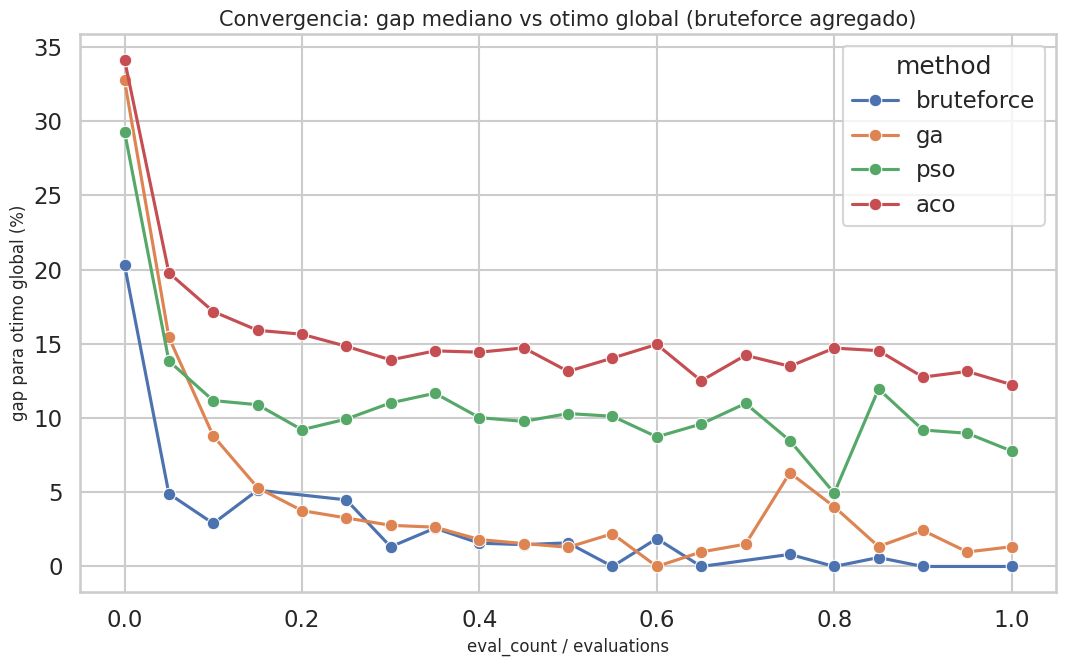

In [32]:
if evolution_df.empty:
    print("Sem dados em evolution para plotar convergencia vs bruteforce global.")
else:
    bf_final = (
        runs_df[runs_df["method"] == "bruteforce"]
        .groupby("instance", as_index=False)["best_makespan"]
        .median()
        .rename(columns={"best_makespan": "bf_optimal"})
    )

    if bf_final.empty:
        print("Sem execucoes de bruteforce para usar como otimo global.")
    else:
        evo = evolution_df.merge(
            runs_df[["run_id", "method", "instance", "evaluations"]],
            on=["run_id", "method"],
            how="left",
        )
        evo = evo.merge(bf_final, on="instance", how="left")
        evo = evo.dropna(subset=["bf_optimal", "evaluations"]).copy()
        evo = evo[evo["bf_optimal"] > 0].copy()

        evo["eval_ratio"] = (evo["eval_count"] / evo["evaluations"]).clip(0, 1)
        evo["gap_to_optimal_pct"] = (
            100 * (evo["best_makespan"] - evo["bf_optimal"]) / evo["bf_optimal"]
        )

        final_points = runs_df.merge(bf_final, on="instance", how="inner")[
            ["method", "best_makespan", "bf_optimal"]
        ].copy()
        final_points = final_points[final_points["bf_optimal"] > 0].copy()
        final_points["eval_ratio"] = 1.0
        final_points["gap_to_optimal_pct"] = (
            100 * (final_points["best_makespan"] - final_points["bf_optimal"])
            / final_points["bf_optimal"]
        )

        conv_points = pd.concat(
            [
                evo[["method", "eval_ratio", "gap_to_optimal_pct"]],
                final_points[["method", "eval_ratio", "gap_to_optimal_pct"]],
            ],
            ignore_index=True,
        )

        conv_points["eval_bin"] = (conv_points["eval_ratio"] * 20).round() / 20
        curve = conv_points.groupby(["method", "eval_bin"], as_index=False)["gap_to_optimal_pct"].median()

        plt.figure(figsize=(11, 7))
        sns.lineplot(
            data=curve,
            x="eval_bin",
            y="gap_to_optimal_pct",
            hue="method",
            hue_order=[m for m in method_order if m in curve["method"].unique()],
            marker="o",
        )
        plt.title("Convergencia: gap mediano vs otimo global (bruteforce agregado)")
        plt.xlabel("eval_count / evaluations")
        plt.ylabel("gap para otimo global (%)")
        plt.tight_layout()
        plt.show()



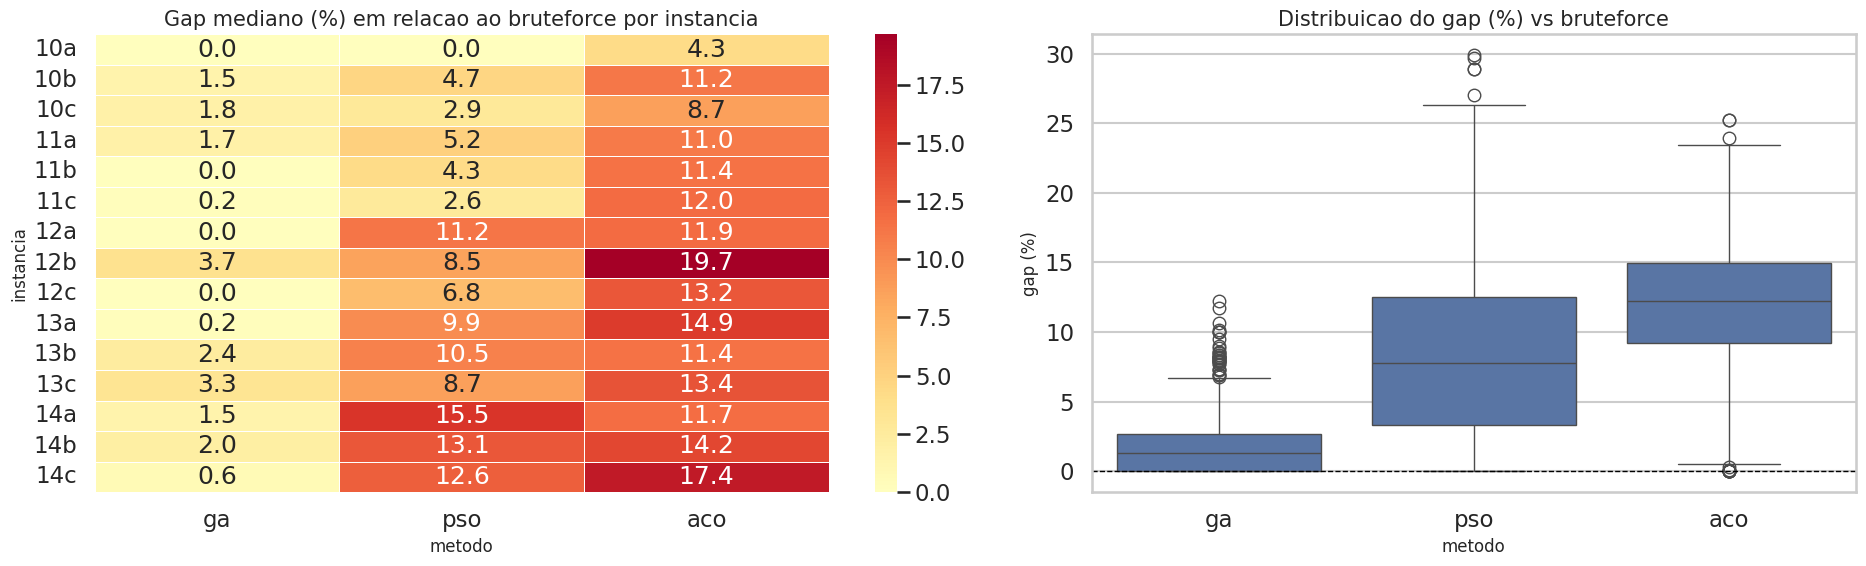

In [33]:
bf = (
    runs_df[runs_df["method"] == "bruteforce"]
    .groupby("instance", as_index=False)["best_makespan"]
    .median()
    .rename(columns={"best_makespan": "bf_best"})
)
gap_df = runs_df.merge(bf, on="instance", how="inner")
gap_df = gap_df[gap_df["method"] != "bruteforce"].copy()

if gap_df.empty:
    print("Sem baseline de bruteforce suficiente para calcular gap - analise sera pulada.")
else:
    gap_df["gap_vs_bf_pct"] = 100 * (gap_df["best_makespan"] - gap_df["bf_best"]) / gap_df["bf_best"]

    gap_matrix = gap_df.pivot_table(
        index="instance", columns="method", values="gap_vs_bf_pct", aggfunc="median"
    )
    method_order_gap = [m for m in method_order if m in gap_matrix.columns]
    instance_order_gap = [inst for inst in instance_order if inst in gap_matrix.index]
    gap_matrix = gap_matrix.reindex(index=instance_order_gap, columns=method_order_gap)

    fig, axes = plt.subplots(1, 2, figsize=(19, 6), gridspec_kw={"width_ratios": [1.2, 1]})
    sns.heatmap(
        gap_matrix,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn_r",
        center=0,
        linewidths=0.5,
        ax=axes[0],
    )
    axes[0].set_title("Gap mediano (%) em relacao ao bruteforce por instancia")
    axes[0].set_xlabel("metodo")
    axes[0].set_ylabel("instancia")

    sns.boxplot(data=gap_df, x="method", y="gap_vs_bf_pct", order=method_order_gap, ax=axes[1])
    axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Distribuicao do gap (%) vs bruteforce")
    axes[1].set_xlabel("metodo")
    axes[1].set_ylabel("gap (%)")

    plt.tight_layout()
    plt.show()



In [34]:
if runs_seed_agg_df.empty:
    print("Sem dados para montar resumo estatistico por metodo.")
else:
    method_summary = (
        runs_seed_agg_df.groupby("method", as_index=False)
        .agg(
            instance_method_pairs=("instance", "count"),
            instances=("instance", pd.Series.nunique),
            seeds_mean=("seeds", "mean"),
            best_makespan_mean=("best_makespan", "mean"),
            best_makespan_median=("best_makespan", "median"),
            best_makespan_min=("best_makespan", "min"),
            total_ms_mean=("total_ms", "mean"),
            total_ms_median=("total_ms", "median"),
            mk_range_pct_mean=("mk_range_pct", "mean"),
            mk_range_pct_median=("mk_range_pct", "median"),
            improvement_points_mean=("improvement_points", "mean"),
            last_eval_ratio_mean=("last_eval_ratio", "mean"),
        )
        .sort_values("best_makespan_mean")
    )

    print("--- resumo por metodo ---")
    print(method_summary)

    if "bootstrap_ci_median" not in globals():
        def bootstrap_ci_median(
            values: pd.Series,
            n_boot: int = 1500,
            ci: float = 95.0,
            seed: int = 42,
        ) -> tuple[float, float]:
            vals = values.dropna().to_numpy(dtype=float)
            if len(vals) == 0:
                return np.nan, np.nan
            if len(vals) == 1 or np.allclose(vals, vals[0]):
                return float(vals[0]), float(vals[0])

            rng = np.random.default_rng(seed)
            samples = rng.choice(vals, size=(n_boot, len(vals)), replace=True)
            medians = np.median(samples, axis=1)
            alpha = (100 - ci) / 2
            return float(np.percentile(medians, alpha)), float(np.percentile(medians, 100 - alpha))

    comparable = runs_df.dropna(subset=["best_makespan", "total_ms", "instance", "seed", "method"]).copy()
    comparable["best_ref"] = comparable.groupby(["instance", "seed"])["best_makespan"].transform("min")
    comparable["fast_ref"] = comparable.groupby(["instance", "seed"])["total_ms"].transform("min")
    comparable = comparable[(comparable["best_ref"] > 0) & (comparable["fast_ref"] > 0)].copy()

    comparable["quality_gap_pct"] = (
        100 * (comparable["best_makespan"] - comparable["best_ref"]) / comparable["best_ref"]
    )
    comparable["runtime_gap_pct"] = (
        100 * (comparable["total_ms"] - comparable["fast_ref"]) / comparable["fast_ref"]
    )

    rank_rows = []
    for method in method_order:
        method_rows = comparable[comparable["method"] == method].copy()
        if method_rows.empty:
            continue

        quality_ci_low, quality_ci_high = bootstrap_ci_median(
            method_rows["quality_gap_pct"],
            n_boot=2000,
            seed=100 + method_order.index(method),
        )
        runtime_ci_low, runtime_ci_high = bootstrap_ci_median(
            method_rows["runtime_gap_pct"],
            n_boot=2000,
            seed=500 + method_order.index(method),
        )

        seed_var = runs_seed_agg_df[runs_seed_agg_df["method"] == method]["mk_range_pct"].dropna()
        seed_var_median = float(seed_var.median()) if not seed_var.empty else np.nan
        seed_var_iqr = (
            float(seed_var.quantile(0.75) - seed_var.quantile(0.25)) if not seed_var.empty else np.nan
        )

        rank_rows.append(
            {
                "method": method,
                "samples": int(len(method_rows)),
                "instances": int(method_rows["instance"].nunique()),
                "seeds": int(method_rows["seed"].nunique()),
                "quality_gap_median_pct": float(method_rows["quality_gap_pct"].median()),
                "quality_gap_iqr_pct": float(
                    method_rows["quality_gap_pct"].quantile(0.75)
                    - method_rows["quality_gap_pct"].quantile(0.25)
                ),
                "quality_gap_ci95_low": quality_ci_low,
                "quality_gap_ci95_high": quality_ci_high,
                "runtime_gap_median_pct": float(method_rows["runtime_gap_pct"].median()),
                "runtime_gap_iqr_pct": float(
                    method_rows["runtime_gap_pct"].quantile(0.75)
                    - method_rows["runtime_gap_pct"].quantile(0.25)
                ),
                "runtime_gap_ci95_low": runtime_ci_low,
                "runtime_gap_ci95_high": runtime_ci_high,
                "seed_variability_median_pct": seed_var_median,
                "seed_variability_iqr_pct": seed_var_iqr,
                "win_rate_pct": float((method_rows["quality_gap_pct"] <= 1e-9).mean() * 100),
            }
        )

    ranking_df = pd.DataFrame(rank_rows)

    if ranking_df.empty:
        print("Sem dados comparaveis para ranking final.")
    else:
        ranking_df["rank_quality"] = ranking_df["quality_gap_median_pct"].rank(method="min", ascending=True)
        ranking_df["rank_robustness"] = ranking_df["seed_variability_median_pct"].rank(
            method="min", ascending=True
        )
        ranking_df["rank_runtime"] = ranking_df["runtime_gap_median_pct"].rank(method="min", ascending=True)

        ranking_df["ranking_score"] = (
            0.60 * ranking_df["rank_quality"]
            + 0.25 * ranking_df["rank_robustness"]
            + 0.15 * ranking_df["rank_runtime"]
        )
        ranking_df["rank_final"] = ranking_df["ranking_score"].rank(method="min", ascending=True)

        ranking_df = ranking_df.sort_values(["rank_final", "ranking_score", "method"]).reset_index(drop=True)

        print("\n--- ranking final por metodo (mediana + robustez por seed) ---")
        print(
            ranking_df[
                [
                    "rank_final",
                    "method",
                    "quality_gap_median_pct",
                    "quality_gap_iqr_pct",
                    "quality_gap_ci95_low",
                    "quality_gap_ci95_high",
                    "seed_variability_median_pct",
                    "seed_variability_iqr_pct",
                    "runtime_gap_median_pct",
                    "runtime_gap_iqr_pct",
                    "win_rate_pct",
                    "ranking_score",
                ]
            ].to_string(index=False, float_format=lambda v: f"{v:.3f}")
        )



--- resumo por metodo ---
       method  instance_method_pairs  instances  seeds_mean  \
1  bruteforce                     15         15         3.4   
2          ga                     30         30        51.0   
3         pso                     30         30        51.0   
0         aco                     30         30        51.0   

   best_makespan_mean  best_makespan_median  best_makespan_min  total_ms_mean  \
1           12.565053             12.677831           8.961151   1.307502e+06   
2           30.704776             14.739782           9.096465   6.470000e+01   
3           35.982776             16.416634           9.384314   7.283333e+01   
0           38.042739             16.857605           9.964725   5.230333e+02   

   total_ms_median  mk_range_pct_mean  mk_range_pct_median  \
1          68374.0           0.000000             0.000000   
2             36.0          11.728919            10.778762   
3             38.5          18.751148            19.146839   
0   

In [35]:
def map_load_points(instance: str, results_dir: Path) -> np.ndarray:
    points_file = results_dir.parent / f"{instance}.points"
    if not points_file.exists():
        raise FileNotFoundError(f"Arquivo de pontos nao encontrado: {points_file}")

    with points_file.open("r", encoding="utf-8") as fh:
        data = json.load(fh)

    pts = np.asarray(data, dtype=float)
    if pts.ndim != 2 or pts.shape[1] != 2:
        raise ValueError(f"Formato invalido de pontos em {points_file}")
    return pts


def map_normalize_sequence(seq: list[int], n_points: int) -> list[int]:
    if not isinstance(seq, list):
        return []

    out = []
    for raw in seq:
        try:
            node = int(raw)
        except (TypeError, ValueError):
            continue

        if node == 0:
            continue

        if 0 < node < n_points:
            out.append(node)

    return out


def map_build_full_route(seq: list[int], n_points: int) -> list[int]:
    normalized = map_normalize_sequence(seq, n_points)
    return [0] + normalized + [0]


def map_pick_run_per_method(df: pd.DataFrame, instance: str, run_selection: str = "median_seed") -> pd.DataFrame:
    subset = df[df["instance"] == instance].copy()
    if subset.empty:
        return subset

    if run_selection == "best":
        subset = subset.sort_values(["method", "best_makespan", "finished_at"], ascending=[True, True, False])
    elif run_selection == "latest":
        subset = subset.sort_values(["method", "finished_at", "best_makespan"], ascending=[True, False, True])
    elif run_selection == "seed0":
        subset = subset[subset["seed"] == 0].copy()
        subset = subset.sort_values(["method", "finished_at", "best_makespan"], ascending=[True, False, True])
    elif run_selection == "median_seed":
        median_by_method = subset.groupby("method")["best_makespan"].transform("median")
        subset["distance_to_median"] = (subset["best_makespan"] - median_by_method).abs()
        subset = subset.sort_values(
            ["method", "distance_to_median", "finished_at", "best_makespan"],
            ascending=[True, True, False, True],
        )
    else:
        raise ValueError(f"run_selection invalido: {run_selection}")

    return subset.groupby("method", as_index=False).head(1).reset_index(drop=True)


def map_choose_default_instance(df: pd.DataFrame) -> str:
    grouped = df.groupby("instance")["method"].apply(lambda s: set(s.dropna()))

    for instance in sorted(grouped.index.tolist(), key=instance_sort_key):
        methods = grouped.loc[instance]
        if "bruteforce" in methods and len(methods - {"bruteforce"}) >= 1:
            return instance

    return sorted(grouped.index.tolist(), key=instance_sort_key)[0]


def map_default_primary_method(runs_for_instance: pd.DataFrame) -> str:
    methods = runs_for_instance["method"].dropna().tolist()
    heuristics = [m for m in METHOD_ORDER if m in methods and m != "bruteforce"]
    if heuristics:
        return heuristics[0]
    if methods:
        return methods[0]
    raise ValueError("Sem metodos para a instancia selecionada.")


def map_setup_axis(ax: plt.Axes, points: np.ndarray, title: str) -> None:
    ax.scatter(points[:, 0], points[:, 1], s=35, color="#aaaaaa", alpha=0.85, zorder=1)
    ax.scatter(points[0, 0], points[0, 1], s=120, color="#2ca02c", edgecolor="black", linewidth=0.8, zorder=3)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, alpha=0.25)


def map_annotate_nodes(ax: plt.Axes, points: np.ndarray, show_node_ids: bool) -> None:
    if not show_node_ids:
        return

    for node, (x, y) in enumerate(points):
        ax.text(x + 0.015, y + 0.015, str(node), fontsize=9, color="#333333")


def map_plot_route(
    ax: plt.Axes,
    points: np.ndarray,
    seq: list[int],
    method: str,
    makespan: float | None,
    show_node_ids: bool = True,
    show_visit_order: bool = True,
) -> None:
    n_points = len(points)
    full_route = map_build_full_route(seq, n_points)

    color = MAP_METHOD_COLORS.get(method, "#1f77b4")
    label = f"{method}"
    if makespan is not None and not pd.isna(makespan):
        label += f" | mksp={makespan:.3f}"

    xs = [points[node, 0] for node in full_route]
    ys = [points[node, 1] for node in full_route]
    ax.plot(xs, ys, "-o", color=color, linewidth=2.2, markersize=4.8, alpha=0.95, label=label, zorder=2)

    for i in range(len(full_route) - 1):
        x1, y1 = points[full_route[i]]
        x2, y2 = points[full_route[i + 1]]
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops={
                "arrowstyle": "->",
                "color": color,
                "lw": 1.2,
                "alpha": 0.75,
                "shrinkA": 6,
                "shrinkB": 6,
            },
        )

    if show_visit_order:
        normalized = map_normalize_sequence(seq, n_points)
        for order, node in enumerate(normalized, start=1):
            x, y = points[node]
            ax.text(
                x - 0.02,
                y - 0.02,
                str(order),
                fontsize=8,
                color=color,
                bbox={"facecolor": "white", "edgecolor": color, "alpha": 0.75, "boxstyle": "round,pad=0.2"},
            )

    map_annotate_nodes(ax, points, show_node_ids=show_node_ids)
    ax.legend(loc="best", fontsize=9)



In [36]:
MAP_RUN_SELECTION = "best"  # "median_seed", "latest", "best", "seed0"
MAP_TARGET_INSTANCE = "14a"  # ex: "13c"
MAP_PRIMARY_METHOD = "pso"  # ex: "ga"
MAP_SHOW_NODE_IDS = True
MAP_SHOW_VISIT_ORDER = True

if MAP_TARGET_INSTANCE is None:
    MAP_TARGET_INSTANCE = map_choose_default_instance(runs_df)

map_runs = map_pick_run_per_method(runs_df, MAP_TARGET_INSTANCE, run_selection=MAP_RUN_SELECTION)
if map_runs.empty:
    raise ValueError(f"Nao ha runs para a instancia {MAP_TARGET_INSTANCE}")

if MAP_PRIMARY_METHOD is None:
    MAP_PRIMARY_METHOD = map_default_primary_method(map_runs)

map_points = map_load_points(MAP_TARGET_INSTANCE, RESULTS_DIR)

print(f"Instancia mapa: {MAP_TARGET_INSTANCE}")
print(f"Metodo principal: {MAP_PRIMARY_METHOD}")
print(
    map_runs[["method", "seed", "run_id", "best_makespan", "evaluations", "seq_len"]]
    .sort_values("method")
    .to_string(index=False)
)



Instancia mapa: 14a
Metodo principal: pso
    method  seed                         run_id  best_makespan  evaluations  seq_len
       aco    37       14a__aco__s37__h12acbaa4      13.941468        10000       13
bruteforce     0 14a__bruteforce__s0__h6fd18092      13.538745   6227020800       13
        ga    48        14a__ga__s48__h12b8af4c      13.538745        10100       13
       pso    13       14a__pso__s13__h7836fca3      13.741509        10100       13


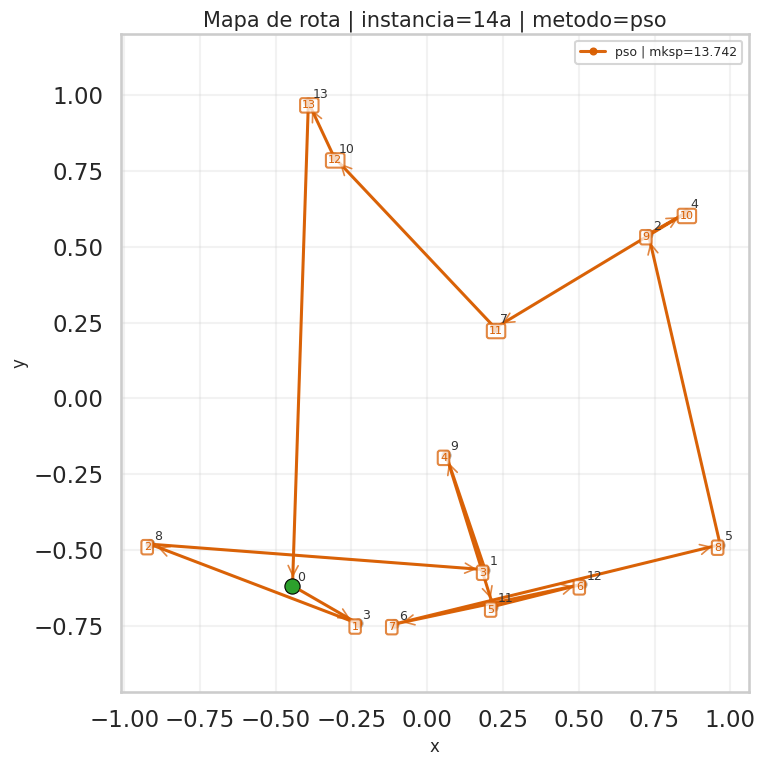

In [37]:

map_row_primary = map_runs[map_runs["method"] == MAP_PRIMARY_METHOD]
if map_row_primary.empty:
    raise ValueError(f"Metodo '{MAP_PRIMARY_METHOD}' nao disponivel para {MAP_TARGET_INSTANCE}")

map_row_primary = map_row_primary.iloc[0]

fig, ax = plt.subplots(figsize=(8, 8))
map_setup_axis(ax, map_points, f"Mapa de rota | instancia={MAP_TARGET_INSTANCE} | metodo={MAP_PRIMARY_METHOD}")
map_plot_route(
    ax,
    map_points,
    map_row_primary["best_sequence"],
    method=map_row_primary["method"],
    makespan=map_row_primary["best_makespan"],
    show_node_ids=MAP_SHOW_NODE_IDS,
    show_visit_order=MAP_SHOW_VISIT_ORDER,
)
plt.tight_layout()
plt.show()




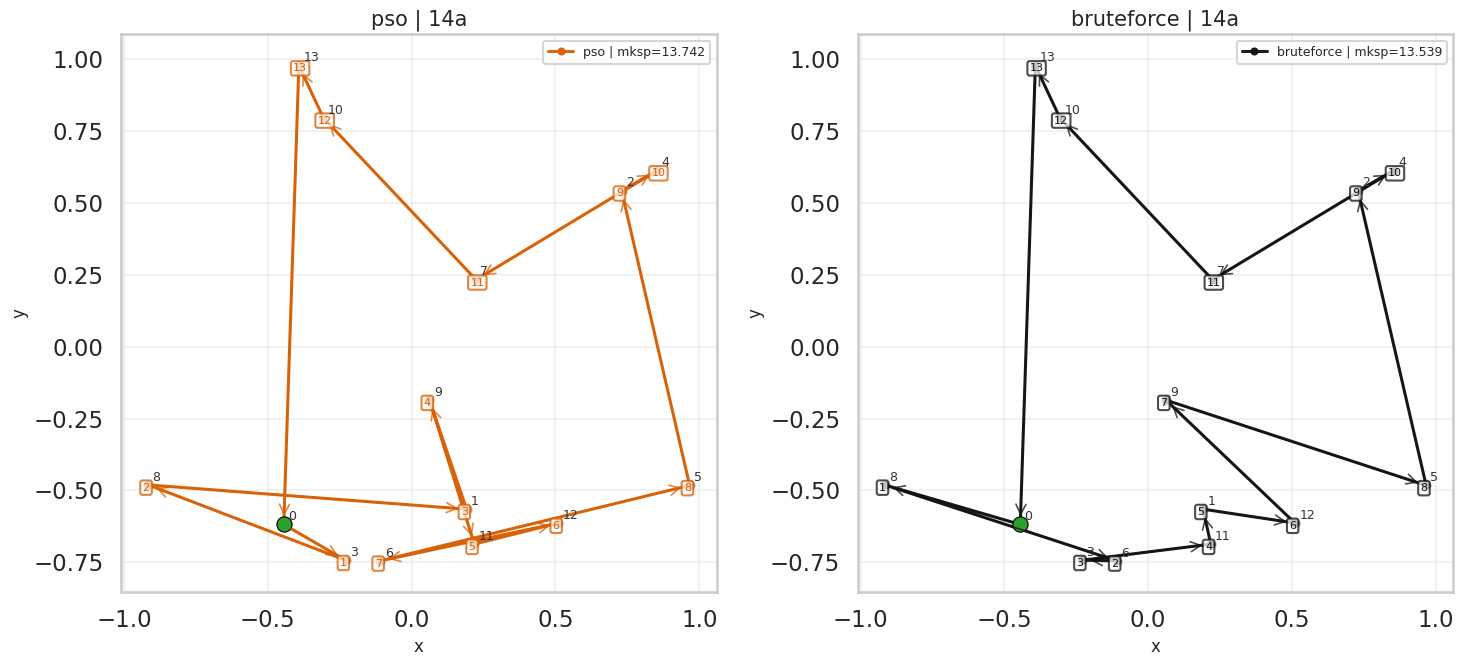

In [38]:


map_row_bf = map_runs[map_runs["method"] == "bruteforce"]

if map_row_bf.empty:
    print(f"Instancia {MAP_TARGET_INSTANCE} nao possui bruteforce para comparacao.")
else:
    map_row_bf = map_row_bf.iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    map_setup_axis(axes[0], map_points, f"{MAP_PRIMARY_METHOD} | {MAP_TARGET_INSTANCE}")
    map_plot_route(
        axes[0],
        map_points,
        map_row_primary["best_sequence"],
        method=map_row_primary["method"],
        makespan=map_row_primary["best_makespan"],
        show_node_ids=MAP_SHOW_NODE_IDS,
        show_visit_order=MAP_SHOW_VISIT_ORDER,
    )

    map_setup_axis(axes[1], map_points, f"bruteforce | {MAP_TARGET_INSTANCE}")
    map_plot_route(
        axes[1],
        map_points,
        map_row_bf["best_sequence"],
        method=map_row_bf["method"],
        makespan=map_row_bf["best_makespan"],
        show_node_ids=MAP_SHOW_NODE_IDS,
        show_visit_order=MAP_SHOW_VISIT_ORDER,
    )

    plt.tight_layout()
    plt.show()

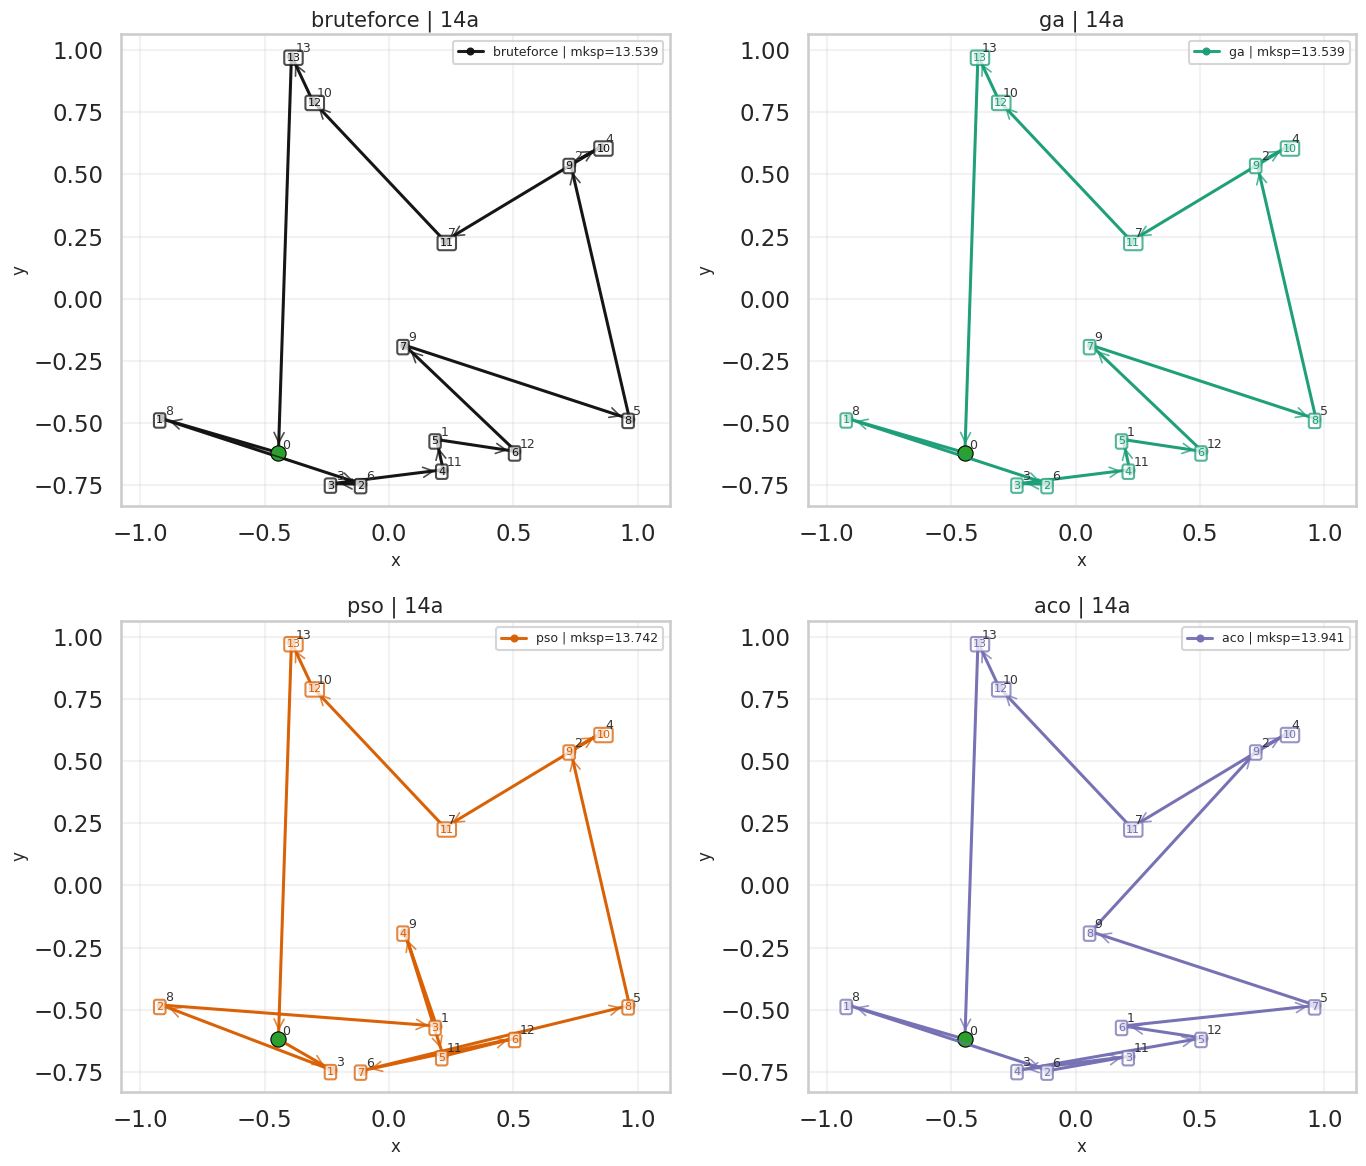

In [39]:
map_methods_present = map_runs["method"].dropna().tolist()
map_heuristics = [m for m in METHOD_ORDER if m in map_methods_present and m != "bruteforce"]

if not map_heuristics:
    print(f"Instancia {MAP_TARGET_INSTANCE} nao possui metodos heurisiticos para comparar.")
else:
    panel_methods = []
    if "bruteforce" in map_methods_present:
        panel_methods.append("bruteforce")
    panel_methods.extend(map_heuristics)

    cols = 2
    rows = ceil(len(panel_methods) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 6))
    axes = np.atleast_1d(axes).flatten()

    for idx, method in enumerate(panel_methods):
        ax = axes[idx]
        row = map_runs[map_runs["method"] == method].iloc[0]
        map_setup_axis(ax, map_points, f"{method} | {MAP_TARGET_INSTANCE}")
        map_plot_route(
            ax,
            map_points,
            row["best_sequence"],
            method=row["method"],
            makespan=row["best_makespan"],
            show_node_ids=MAP_SHOW_NODE_IDS,
            show_visit_order=MAP_SHOW_VISIT_ORDER,
        )

    for idx in range(len(panel_methods), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()



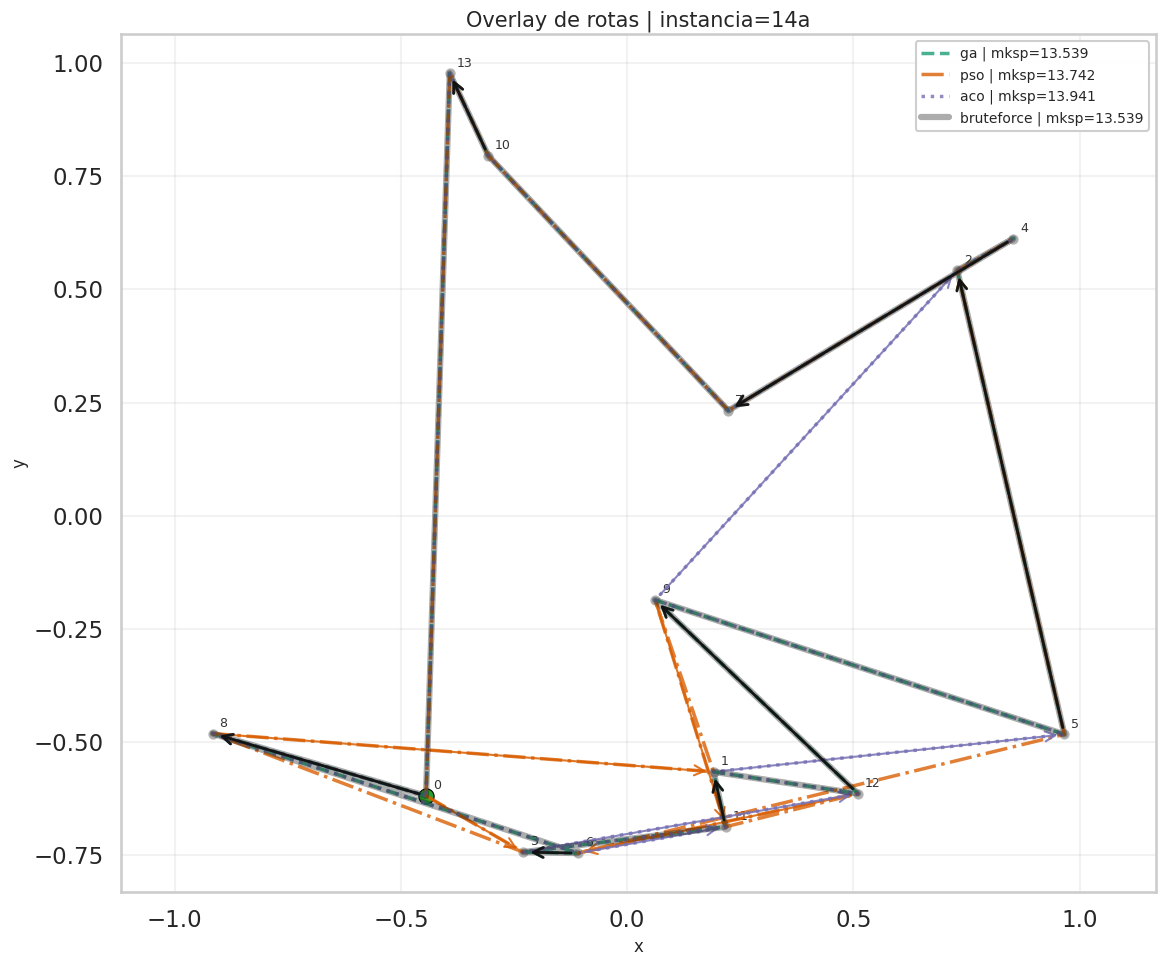

In [40]:
overlay_order = [m for m in METHOD_ORDER if m in map_runs["method"].tolist()]
if not overlay_order:
    raise ValueError("Nenhum metodo disponivel para overlay.")

fig, ax = plt.subplots(figsize=(12, 10))
map_setup_axis(ax, map_points, f"Overlay de rotas | instancia={MAP_TARGET_INSTANCE}")
map_annotate_nodes(ax, map_points, show_node_ids=MAP_SHOW_NODE_IDS)

# Definir estilos de linha diferentes para cada método
line_styles = {
    "bruteforce": "-",
    "ga": "--",
    "pso": "-.",
    "aco": ":",
}

# Priorizar bruteforce - desenhar por último para ficar no topo
methods_to_plot = [m for m in overlay_order if m != "bruteforce"]
if "bruteforce" in overlay_order:
    methods_to_plot.append("bruteforce")

for method in methods_to_plot:
    row = map_runs[map_runs["method"] == method].iloc[0]
    full_route = map_build_full_route(row["best_sequence"], len(map_points))

    xs = [map_points[node, 0] for node in full_route]
    ys = [map_points[node, 1] for node in full_route]

    color = MAP_METHOD_COLORS.get(method, None)
    linestyle = line_styles.get(method, "-")
    
    # Aumentar espessura para bruteforce
    linewidth = 4.5 if method == "bruteforce" else 2.5
    alpha = 0.35 if method == "bruteforce" else 0.8
    markersize = 6 if method == "bruteforce" else 5
    zorder = 10 if method == "bruteforce" else 5
    
    label = f"{method} | mksp={row['best_makespan']:.3f}"
    ax.plot(xs, ys, linestyle=linestyle, linewidth=linewidth, markersize=markersize, 
            alpha=alpha, color=color, label=label, zorder=zorder)

    # Adicionar setas espaçadas para melhor visualização
    for i in range(0, len(full_route) - 1, max(1, len(full_route) // 6)):
        x1, y1 = map_points[full_route[i]]
        x2, y2 = map_points[full_route[i + 1]]
        
        arrow_lw = 2.0 if method == "bruteforce" else 1.5
        arrow_alpha = 0.95 if method == "bruteforce" else 0.85
        
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops={
                "arrowstyle": "->",
                "color": color,
                "lw": arrow_lw,
                "alpha": arrow_alpha,
                "shrinkA": 5,
                "shrinkB": 5,
            },
            zorder=zorder,
        )

ax.legend(loc="best", fontsize=10, framealpha=0.95)
plt.tight_layout()
plt.show()